In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection   import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing     import StandardScaler
from sklearn.linear_model      import LinearRegression
from sklearn.tree              import DecisionTreeRegressor
from sklearn.ensemble          import GradientBoostingRegressor
from sklearn.metrics           import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

In [ ]:
URL = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
print("Loading dataset...\n")

df = pd.read_csv(URL)
df.rename(columns={"medv": "PRICE"}, inplace=True)
print(f"Shape : {df.shape}\n")
print(f"Columns : {list(df.columns)}\n")

Loading dataset...

Shape : (506, 14)

Columns : ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'PRICE']



  STEP 1 — DATA PREPROCESSING

First 5 rows:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio       b  lstat  PRICE
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3  396.90   4.98   24.0
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8  396.90   9.14   21.6
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8  392.83   4.03   34.7
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7  394.63   2.94   33.4
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7  396.90   5.33   36.2

Dataset Statistics:
         crim      zn   indus    chas     nox      rm     age     dis     rad     tax  ptratio       b   lstat   PRICE
count  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00  506.00   506.00  506.00  506.00  506.00
mean     3.61   11.36   11.14    0.07    0.55    6.28   68.57    3.80    9.55  408.24    18.46  356.67

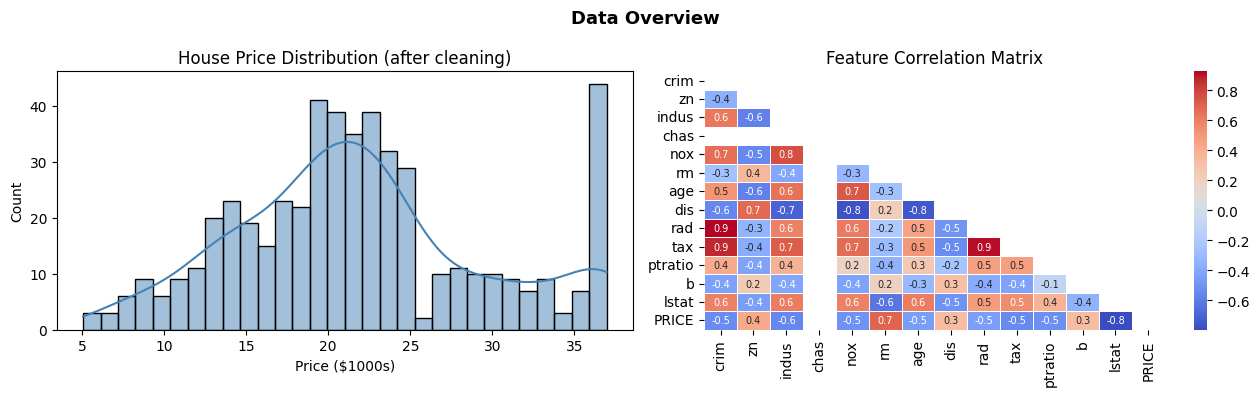

Feature|Target Split|Scaling

   Train : 404 samples  |  Test : 102 samples


In [ ]:
print("  STEP 1 — DATA PREPROCESSING")
print("\nFirst 5 rows:")
print(df.head().to_string())
print("\nDataset Statistics:")
print(df.describe().round(2).to_string())

print("\nMissing Values per Column:")
missing = df.isnull().sum()
print(missing[missing > 0].to_string() if missing.sum() > 0 else "   None found ")
df.fillna(df.median(numeric_only=True), inplace=True)
print(f"   Total missing after imputation: {df.isnull().sum().sum()}")

print("\nOutlier Capping using IQR method:")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_summary = {}
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    n_out  = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_out > 0:
        df[col] = df[col].clip(lower, upper)
        outlier_summary[col] = n_out
        print(f"   {col:<12} → {n_out} outliers capped  [{lower:.2f}, {upper:.2f}]")
if not outlier_summary:
    print("   No significant outliers found")

print("\nVisualized clean data")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df["PRICE"], kde=True, color="steelblue", bins=30, ax=axes[0])
axes[0].set_title("House Price Distribution (after cleaning)")
axes[0].set_xlabel("Price ($1000s)")

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm",
            mask=mask, linewidths=0.4, ax=axes[1], annot_kws={"size": 7})
axes[1].set_title("Feature Correlation Matrix")

plt.suptitle("Data Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Feature|Target Split|Scaling")
X = df.drop("PRICE", axis=1)
y = df["PRICE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n   Train : {X_train.shape[0]} samples  |  Test : {X_test.shape[0]} samples")


In [ ]:
print("  STEP 2 — MODEL SELECTION")
models_cfg = {
    "Linear Regression":  {"model": LinearRegression(),
                           "scaled": True},
    "Decision Tree":      {"model": DecisionTreeRegressor(random_state=42),
                           "scaled": False},
    "Gradient Boosting":  {"model": GradientBoostingRegressor(random_state=42),
                           "scaled": False},
}

  STEP 2 — MODEL SELECTION


In [ ]:
print("  STEP 3 — TRAINING")
results = {}
for name, cfg in models_cfg.items():
    Xtr = X_train_sc if cfg["scaled"] else X_train
    Xte = X_test_sc  if cfg["scaled"] else X_test
    cfg["model"].fit(Xtr, y_train)
    preds = cfg["model"].predict(Xte)

    mse  = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    results[name] = {"MSE": mse, "RMSE": rmse, "MAE": mae,
                     "R2": r2, "preds": preds, "model": cfg["model"],
                     "scaled": cfg["scaled"]}
    print(f"\n{name} — trained")

  STEP 3 — TRAINING

Linear Regression — trained

Decision Tree — trained

Gradient Boosting — trained


  STEP 4 — EVALUATION

Model Metrics on Test Set:
                       MSE    RMSE     MAE      R²
Linear Regression  12.0112  3.4657  2.4046  0.7545
Decision Tree      12.9787  3.6026  2.3739  0.7347
Gradient Boosting   6.2363  2.4973  1.8216  0.8725

Cross-Validation R² (5-fold, full dataset):
   Linear Regression       mean=0.7684  std=±0.0407
   Decision Tree           mean=0.6956  std=±0.0725
   Gradient Boosting       mean=0.8634  std=±0.0215

Best model before fine-tuning → Gradient Boosting  (R² = 0.8725)


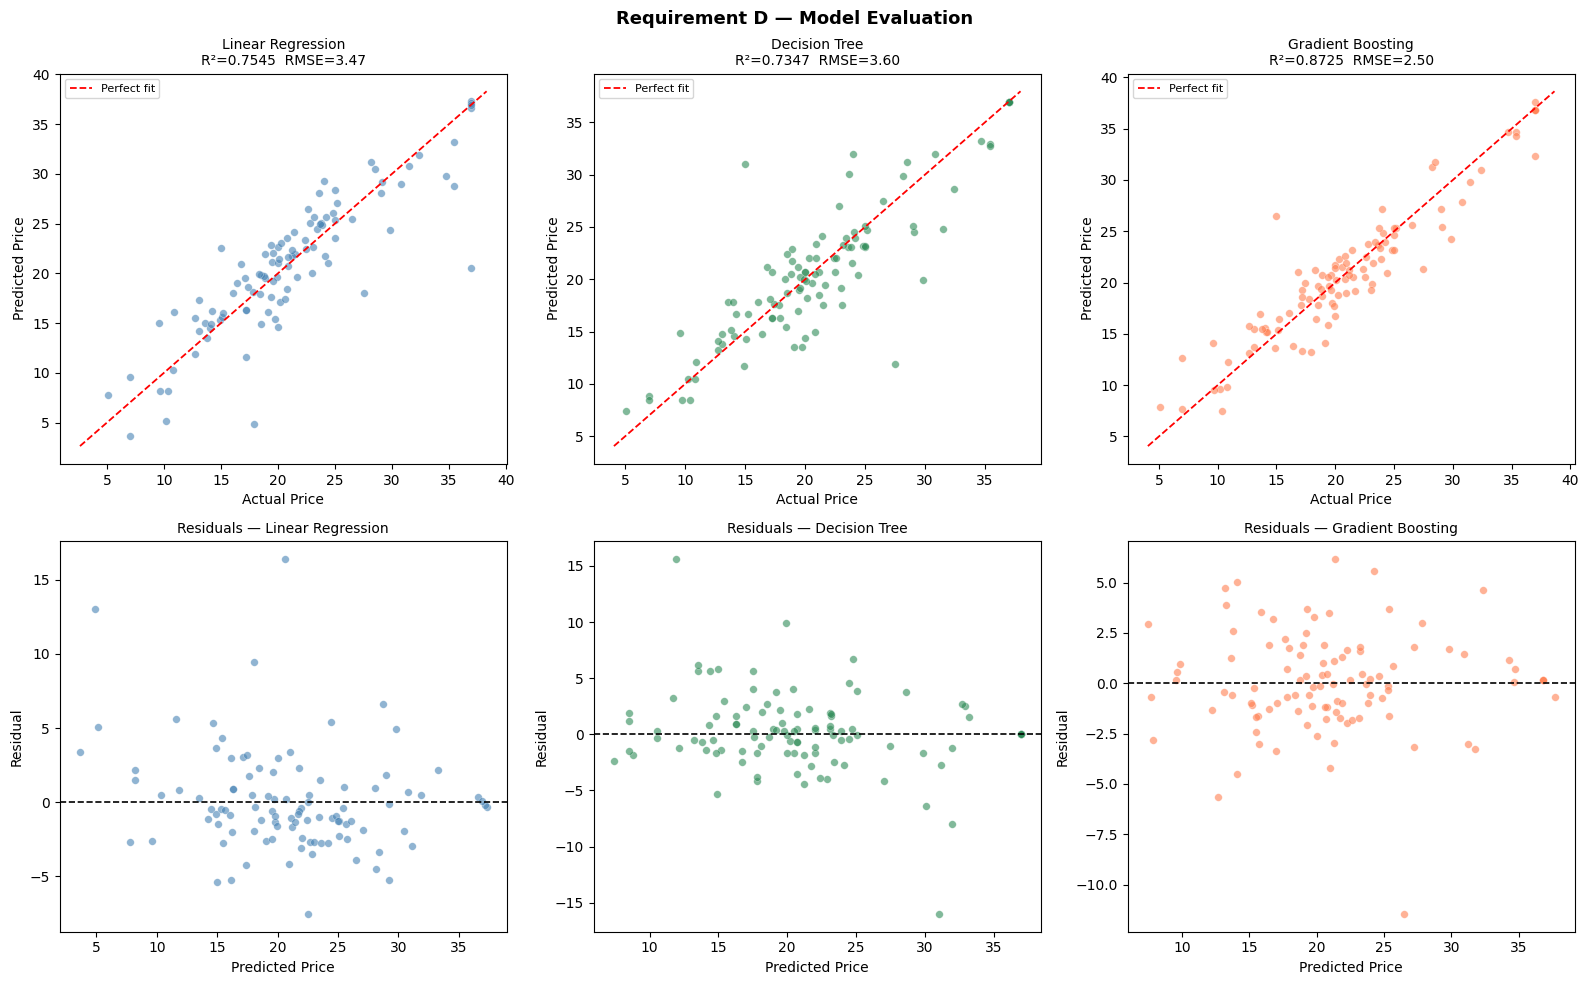

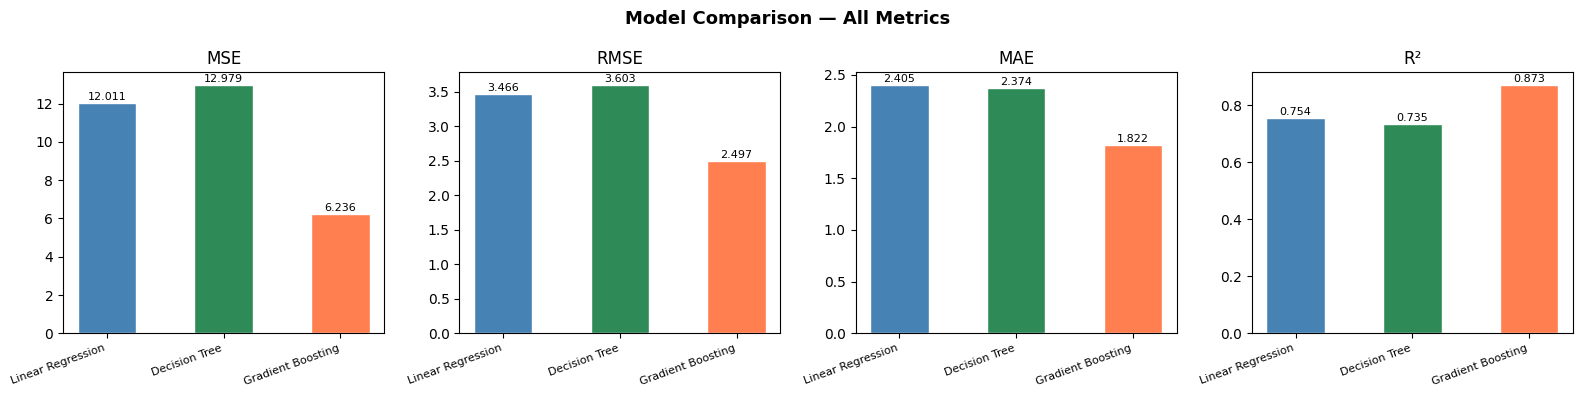

In [ ]:
print("  STEP 4 — EVALUATION")
metrics_df = pd.DataFrame(
    {k: {"MSE": v["MSE"], "RMSE": v["RMSE"], "MAE": v["MAE"], "R²": v["R2"]}
     for k, v in results.items()}
).T.round(4)

print("\nModel Metrics on Test Set:")
print(metrics_df.to_string())


print("\nCross-Validation R² (5-fold, full dataset):")
for name, cfg in models_cfg.items():
    Xfull  = X_train_sc if cfg["scaled"] else X_train
    cv_r2  = cross_val_score(cfg["model"], Xfull, y_train,
                              cv=5, scoring="r2")
    print(f"   {name:<22}  mean={cv_r2.mean():.4f}  std=±{cv_r2.std():.4f}")

best_name = metrics_df["R²"].idxmax()
print(f"\nBest model before fine-tuning → {best_name}"
      f"  (R² = {metrics_df.loc[best_name, 'R²']:.4f})")


fig, axes = plt.subplots(2, 3, figsize=(16, 10))
model_colors = ["steelblue", "seagreen", "coral"]

for idx, (name, res) in enumerate(results.items()):
    ax_top = axes[0][idx]
    ax_bot = axes[1][idx]
    preds  = res["preds"]
    resid  = y_test.values - preds
    color  = model_colors[idx]

    # Actual vs Predicted
    ax_top.scatter(y_test, preds, alpha=0.6, color=color, s=30, edgecolors="white", lw=0.3)
    lims = [min(y_test.min(), preds.min())-1, max(y_test.max(), preds.max())+1]
    ax_top.plot(lims, lims, "r--", lw=1.3, label="Perfect fit")
    ax_top.set_title(f"{name}\nR²={res['R2']:.4f}  RMSE={res['RMSE']:.2f}", fontsize=10)
    ax_top.set_xlabel("Actual Price")
    ax_top.set_ylabel("Predicted Price")
    ax_top.legend(fontsize=8)

    # Residuals
    ax_bot.scatter(preds, resid, alpha=0.6, color=color, s=30, edgecolors="white", lw=0.3)
    ax_bot.axhline(0, color="black", lw=1.2, ls="--")
    ax_bot.set_title(f"Residuals — {name}", fontsize=10)
    ax_bot.set_xlabel("Predicted Price")
    ax_bot.set_ylabel("Residual")

plt.suptitle("Requirement D — Model Evaluation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Metric bar chart
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, metric in enumerate(["MSE", "RMSE", "MAE", "R²"]):
    vals = metrics_df[metric]
    bars = axes[i].bar(vals.index, vals.values,
                       color=["steelblue","seagreen","coral"], edgecolor="white", width=0.5)
    axes[i].set_title(metric, fontsize=12)
    axes[i].set_xticks(range(len(vals)))
    axes[i].set_xticklabels(vals.index, rotation=20, ha="right", fontsize=8)
    for bar, val in zip(bars, vals.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005 * vals.max(),
                     f"{val:.3f}", ha="center", va="bottom", fontsize=8)
plt.suptitle("Model Comparison — All Metrics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()



  STEP 5 — FINE-TUNING (GridSearchCV)
   n_estimators          : [100, 200]
   learning_rate         : [0.05, 0.1, 0.2]
   max_depth             : [3, 4, 5]
   min_samples_split     : [2, 5]

Best hyperparameters found:
   learning_rate         : 0.05
   max_depth             : 3
   min_samples_split     : 2
   n_estimators          : 200
   Best CV R²           : 0.8665

Tuned Gradient Boosting — Test Set Performance:
   MSE  : 6.1898
   RMSE : 2.4879
   MAE  : 1.8515
   R²   : 0.8735

   R² Before fine-tuning : 0.8725
   R² After  fine-tuning : 0.8735
   Improvement           : +0.0010 ✅ improved


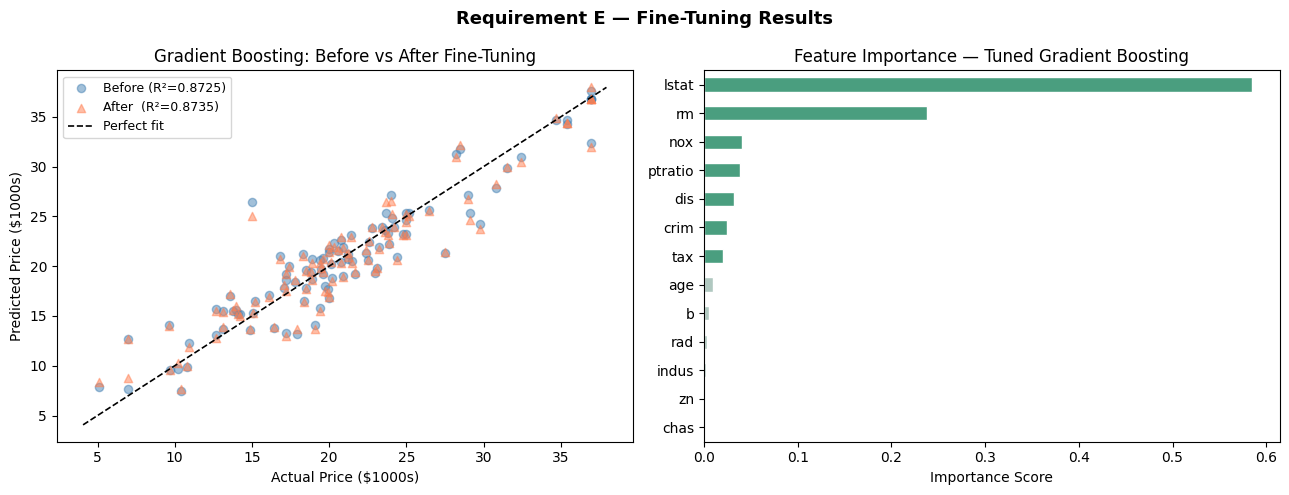

FINAL SUMMARY

                       R²    RMSE      MSE
Linear Regression  0.7545  3.4657  12.0112
Decision Tree      0.7347  3.6026  12.9787
Gradient Boosting  0.8725  2.4973   6.2363
GB Tuned (Best)    0.8735  2.4879   6.1898

Final Best Model : Gradient Boosting (Fine-Tuned)
   R²   = 0.8735  (explains 87.3% of variance)
   RMSE = 2.4879  (avg error ≈ $2,488)
   MSE  = 6.1898
PREDICT A NEW HOUSE  (Tuned Model)

 Predicted Price : $26,573  ($26.57k)


In [ ]:
print("  STEP 5 — FINE-TUNING (GridSearchCV)")
param_grid = {
    "n_estimators":    [100, 200],
    "learning_rate":   [0.05, 0.1, 0.2],
    "max_depth":       [3, 4, 5],
    "min_samples_split": [2, 5],
}
for k, v in param_grid.items():
    print(f"   {k:<22}: {v}")

grid_search = GridSearchCV(
    estimator  = GradientBoostingRegressor(random_state=42),
    param_grid = param_grid,
    cv         = 5,
    scoring    = "r2",
    n_jobs     = -1,
    verbose    = 0,
)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_cv_r2  = grid_search.best_score_
print(f"\nBest hyperparameters found:")
for k, v in best_params.items():
    print(f"   {k:<22}: {v}")
print(f"   Best CV R²           : {best_cv_r2:.4f}")

# Evaluate tuned model on test set
tuned_model  = grid_search.best_estimator_
tuned_preds  = tuned_model.predict(X_test)
tuned_mse    = mean_squared_error(y_test, tuned_preds)
tuned_rmse   = np.sqrt(tuned_mse)
tuned_mae    = mean_absolute_error(y_test, tuned_preds)
tuned_r2     = r2_score(y_test, tuned_preds)

base_gb_r2   = results["Gradient Boosting"]["R2"]
improvement  = tuned_r2 - base_gb_r2

print(f"\nTuned Gradient Boosting — Test Set Performance:")
print(f"   MSE  : {tuned_mse:.4f}")
print(f"   RMSE : {tuned_rmse:.4f}")
print(f"   MAE  : {tuned_mae:.4f}")
print(f"   R²   : {tuned_r2:.4f}")
print(f"\n   R² Before fine-tuning : {base_gb_r2:.4f}")
print(f"   R² After  fine-tuning : {tuned_r2:.4f}")
print(f"   Improvement           : {improvement:+.4f} {'✅ improved' if improvement > 0 else '(already optimal)'}")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Before vs After scatter
axes[0].scatter(y_test, results["Gradient Boosting"]["preds"],
                alpha=0.5, color="steelblue", s=35, label=f"Before (R²={base_gb_r2:.4f})")
axes[0].scatter(y_test, tuned_preds,
                alpha=0.5, color="coral", s=35, marker="^", label=f"After  (R²={tuned_r2:.4f})")
lims = [y_test.min()-1, y_test.max()+1]
axes[0].plot(lims, lims, "k--", lw=1.2, label="Perfect fit")
axes[0].set_xlabel("Actual Price ($1000s)")
axes[0].set_ylabel("Predicted Price ($1000s)")
axes[0].set_title("Gradient Boosting: Before vs After Fine-Tuning")
axes[0].legend(fontsize=9)

# Feature importance of tuned model
feat_imp = pd.Series(tuned_model.feature_importances_,
                     index=X.columns).sort_values(ascending=True)
colors_fi = ["#4A9E7F" if v >= feat_imp.median() else "#B0C8C0"
             for v in feat_imp.values]
feat_imp.plot(kind="barh", color=colors_fi, ax=axes[1], edgecolor="white")
axes[1].set_title("Feature Importance — Tuned Gradient Boosting")
axes[1].set_xlabel("Importance Score")

plt.suptitle("Requirement E — Fine-Tuning Results", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("FINAL SUMMARY")
summary = {
    **{k: {"R²": v["R2"], "RMSE": v["RMSE"], "MSE": v["MSE"]}
       for k, v in results.items()},
    "GB Tuned (Best)": {"R²": tuned_r2, "RMSE": tuned_rmse, "MSE": tuned_mse}
}
summary_df = pd.DataFrame(summary).T.round(4)
print(f"\n{summary_df.to_string()}")
print(f"\nFinal Best Model : Gradient Boosting (Fine-Tuned)")
print(f"   R²   = {tuned_r2:.4f}  (explains {tuned_r2*100:.1f}% of variance)")
print(f"   RMSE = {tuned_rmse:.4f}  (avg error ≈ ${tuned_rmse*1000:,.0f})")
print(f"   MSE  = {tuned_mse:.4f}")


# ── Predict a New House (Tuned Model) ────────────────────────

print("PREDICT A NEW HOUSE  (Tuned Model)")


new_house = pd.DataFrame([{
    "crim": 0.03, "zn": 18.0,  "indus": 2.31, "chas": 0,
    "nox":  0.54, "rm":  6.58, "age":  65.2,  "dis":  4.09,
    "rad":  1,    "tax": 296,  "ptratio": 15.3,
    "b":    396.9,"lstat": 4.98
}])

pred_price = tuned_model.predict(new_house)[0]
print(f"\n Predicted Price : ${pred_price * 1000:,.0f}  (${pred_price:.2f}k)")